# **TS1** Síntesis y operaciones de señales.
García Corona, Iara Paula
Ejercicio 1:

Primero realizo un seteo generalizado y defino mi función seno para el ejericico

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return(tt,xx)
"Frecuencia de la señal"
ff=2000 # Hz ff=1/T
N= 1000 # Muestras totales
nn=np.arange(0,N) #Eje temporal discreto
"Cantidad mínima de muestras por periodo"
mpp=10

"Frecuencia de muestreo"
fs = ff*mpp

Las muestras por periodo se definen como $\frac{f_s}{f} = M$. En este caso como el resto de los items no piden un numero específico de muestras, planteo la frecuencia de muestreo en función l ítem 1 y lo sostengo para el resto. </br> 
Además, se realiza la FFT para cada señal y se grafica en función de **k** para analizar los índices en los cuales el espéctro aporta información relevante.

Punto 1: Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.

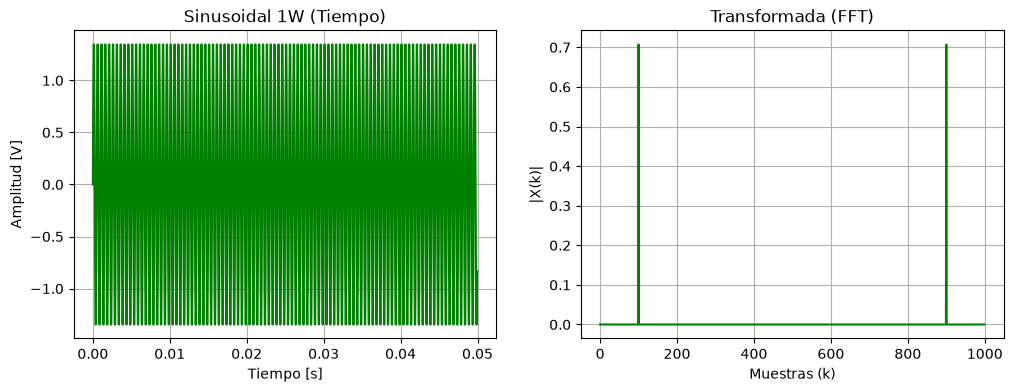

In [2]:
vmax_1=np.sqrt(2)
ph_1=0
dc_1=0 # Valor medio (alrededor del que oscila)
tt_1, xx_1= mi_funcion_sen(vmax_1, dc_1, ff, ph_1, nn, fs)

"FFT"
tr_1=(1/N)*np.fft.fft(xx_1)
modulo_tr_1=np.abs(tr_1)
k = np.arange(0,N)
#fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# --- Gráficos lado a lado ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_1, xx_1, color="green")
ax[0].set_title("Sinusoidal 1W (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(k, modulo_tr_1, color="green")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Muestras (k)")
ax[1].set_ylabel("|X(k)|")
ax[1].grid(True)

En el eje horizontal se ve que los picos se encuentran en k=100 y k=900.</br>
Esto tiene sentido ya que indica que la señal oscila en esa frecuencia. Siendo $f = k \cdot f_s / N$, se puede verificar que para $k=100$, $f=2000Hz$ </br>
Por simetría Hermitiana, se obtiene un segundo pico en su conjugado ($X[k]=X*[N-k]$) (Holton, 2021, p. 672, Ec. 10.25), al aplicar el módulo se obtiene otro pico positivo de igual amplitud a igual distancia de la frecuencia de Nyquist para el intervalo $[N/2;N-1]$ </br> en el eje vertical se ve la amplitud de la frecuencia, al ser los picos los únicos puntos con altura distinta de cero, se puede entender que solo esa frecuencia contribuye a la señal. </br>
(Agrego la cita de donde se extrajo la información para poder consultarlo en el futuro en caso de ser necesario)

Punto 2: Misma señal con 2 W de potencia media y desfasada en π/2.

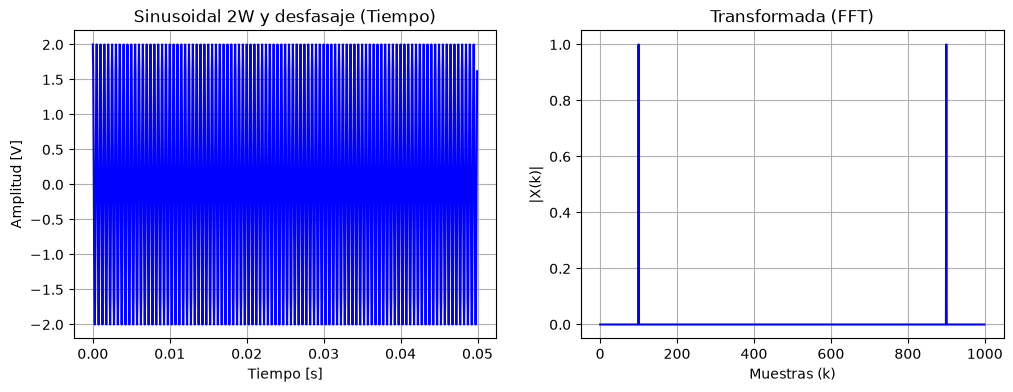

In [6]:
P_m=2 #potencia pedida
vmax_2=np.sqrt(P_m*2)
ph_2=1/4 # Es la proporción que hay que desfasar, la función tiene 2pi*ph
dc_2=0
tt_2, xx_2= mi_funcion_sen(vmax_2, dc_2, ff, ph_2, nn, fs)
"FFT"
tr_2=(1/N)*np.fft.fft(xx_2)
modulo_tr_2=np.abs(tr_2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_2, xx_2, color="orange")
ax[0].set_title("Sinusoidal 2W y desfasaje (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(k, modulo_tr_2, color="orange")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Muestras (k)")
ax[1].set_ylabel("|X(k)|")
ax[1].grid(True)

En este ítem los gráficos resultan muy similares e los analizados en el primer punto, esto se debe a que el aumento de potencia se ve directamente reflejado en el aumento de la amplitud tanto de la onda en función del tiempo como en los picos de la transformada, pero el desfasaje es una componente que se visualiza en la fase del espectro, más no en su magnitud que es lo se grafica.

Punto 3: Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W

La potencia de una señal con valor medio resulta ser igual a su varianza, por lo que se define: $$pot_{ruido}=\sqrt{0.1}$$ y dado que la función pide la variación estander se aplica la raíz a la varianza. Luego se implementa la función que devuelve valores aleatorios enmarcados en una distribución normal. 

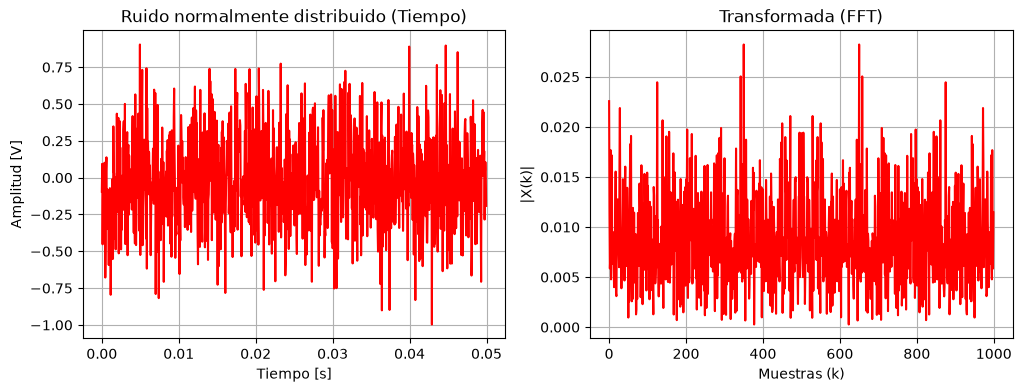

In [17]:
dc_3=0

"Definiciones para el ruido"
mu=0 #valor 
# Para señales con valor medio 0, la potencia media es igual a la varianza. P=sigma^2
sig_ruido=np.sqrt(0.1)# dispersión de los puntos respecto de la media
xx_3=np.random.normal(mu,sig_ruido,N);
tt_3=nn/fs #podría usar siempre el mismo tt pero no quiero modificar la función

"FFT"
tr_3=(1/N)*np.fft.fft(xx_3)
modulo_tr_3=np.abs(tr_3)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_3, xx_3, color="red")
ax[0].set_title("Ruido normalmente distribuido (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(k, modulo_tr_3, color="red")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Muestras (k)")
ax[1].set_ylabel("|X(k)|")
ax[1].grid(True)

Al ser esta una señal de ruido generada de manera aleatorio, se puede ver en el gráfico del tiempo la ausencia de un patrón común. En la FFT no resalta una única frecuencia, sino que se visualizan picos aleatorios, reforzando que hecho de que no hay una periodicidad en la señal sin que resalte ninguna frecuencia.

Punto 4: Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W.

Para el ruido uniformemente distribuido se utiliza que $\int_{a}^{-a} p_X(x) \, dx=1$, sabiendo que la distribución es un escalón, el área debjajo de la curva será el área de un rectángulo. $p_X(x)$ es la altura del rectángulo y la densidad de probabilidad es constante para el intervalo, $p_X(x)=h$, permitiendo despejar $h=\frac{1}{2a}$. </br>
La varianza se define como $sigma^2=\int_{a}^{-a} x^2 p_X(x) \, dx=\frac{a^2}{3}$

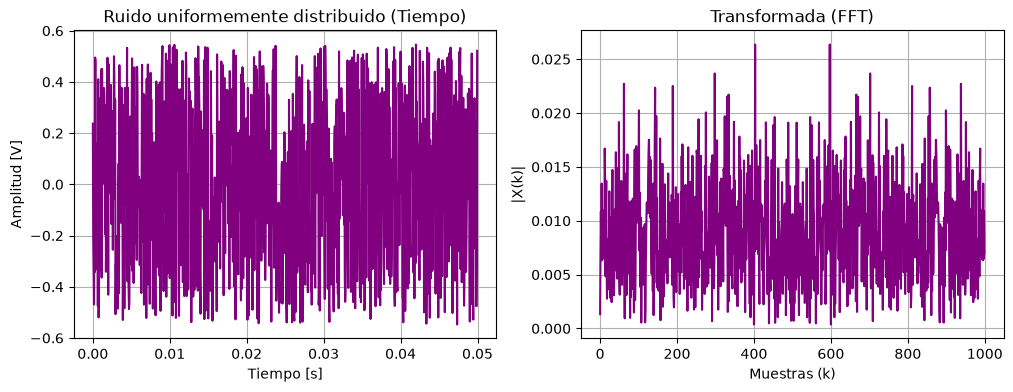

In [18]:
lim=np.sqrt(0.1*3)
xx_4=np.random.uniform(-lim,lim,N);
tt_4=nn/fs

"FFT"
tr_4=(1/N)*np.fft.fft(xx_4)
modulo_tr_4=np.abs(tr_4)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt_4, xx_4, color="purple")
ax[0].set_title("Ruido uniformemente distribuido (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(k, modulo_tr_4, color="purple")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Muestras (k)")
ax[1].set_ylabel("|X(k)|")
ax[1].grid(True)

En este caso, el ruido está acotado entre los límites definidos como $a$ y $-a$ y es posible ver una distribución semejante a un rectángulo. Para el gráfico de la FFT los picos no destacan ninguna frecuencia pero sí tienen una estructura más pareja entre sí, lo cual tiene sentido al recordar el tipo de distribución de la que parte a pesar de su aleatoriedad. 

Punto 5: Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%

Para la onda cuadrada se utiliza la función signal.square definida en la librería scipy.signal. Esta tiene como primer parámetro el punto del ciclo que se está evaluando y el segundo indica el ciclo de actividad. Por lo tanto la mitad de la onda resulta [] postiiva y luego negativa 

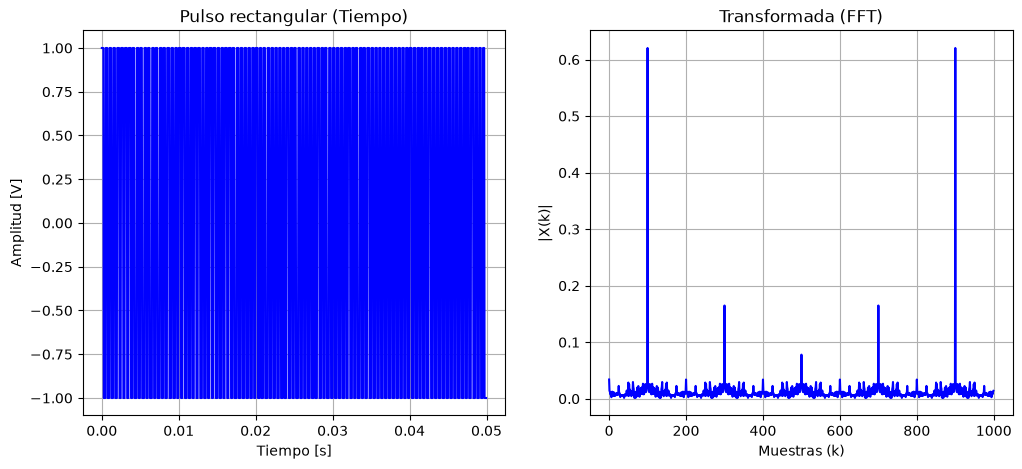

In [11]:
pot_5=1 #
vmax_5=np.sqrt(pot_5)
tt_5=nn/fs #podría usar siempre el mismo tt pero no quiero modificar la función
xx_5=signal.square(2*np.pi*ff*tt_5,0.5)

"FFT"
tr_5=(1/N)*np.fft.fft(xx_5)
modulo_tr_5=np.abs(tr_5)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(tt_5, xx_5, color="blue")
ax[0].set_title("Pulso rectangular (Tiempo)")
ax[0].set_xlabel("Tiempo [s]")
ax[0].set_ylabel("Amplitud [V]")
ax[0].grid(True)

ax[1].plot(k, modulo_tr_5, color="blue")
ax[1].set_title("Transformada (FFT)")
ax[1].set_xlabel("Muestras (k)")
ax[1].set_ylabel("|X(k)|")
ax[1].grid(True)